In [22]:
import pandas as pd
import numpy as np

train_labels = pd.read_csv('/kaggle/input/competitions/soil-grain-size-from-photos/Training_labels_updated.csv')
train_labels 

,sample_id,0.002,0.0063,0.02,0.063,0.2,0.63,2,6.3,20,63,200
0,F827,9.4904,19.3892,47.6257,89.5554,99.8965,99.9896,100.0000,100.0000,100.0000,100.0000,100.0
1,G190,5.2076,10.2425,23.7537,50.3113,75.8311,85.7233,90.9898,94.8969,98.5814,100.0000,100.0
2,H030,6.7833,10.9091,19.0599,37.3235,66.8349,96.4965,97.9530,99.5691,100.0000,100.0000,100.0
3,H037,0.9320,6.4500,16.3216,27.8019,34.6629,46.3652,62.7168,79.0523,89.7830,100.0000,100.0
4,H038,1.8218,5.1400,10.6113,18.2778,24.6420,35.0767,47.2345,63.3992,81.0851,95.7127,100.0
5,H126,6.3330,12.5995,32.5463,68.3599,84.6357,89.5359,94.8473,99.4738,100.0000,100.0000,100.0
6,H181,0.0000,0.0000,0.0000,4.2956,7.8382,17.4746,37.4069,71.2397,95.6027,100.0000,100.0
7,H183,0.0000,0.0000,0.0000,4.9489,8.1046,14.4387,32.2812,65.7083,95.8450,100.0000,100.0
8,H366,0.9633,2.0893,5.0347,9.4833,13.7489,20.2655,32.8170,55.3867,86.2023,100.0000,100.0
9,H367,0.8232,1.8584,4.1483,7.5417,11.0995,17.3609,30.4114,56.1341,85.7588,100.0000,100.0


In [23]:
ppm_data  = pd.read_csv('/kaggle/input/competitions/soil-grain-size-from-photos/ppm_updated.csv')
ppm_data 

,phone,camera,width,height,ppm
0,iPhone 14,iPhone 14,4032,3024,13.942
1,iPhone 16,iPhone 16,5712,4284,19.525
2,Motorola Edge,motorola edge 20,4000,1800,11.492
3,Motorola Edge 60 Fusion,Motorola Edge 60 fusion,4096,2304,12.465
4,Samsung A52,SM-A525F,9248,6936,26.330


In [24]:
sample_sub = pd.read_csv('/kaggle/input/competitions/soil-grain-size-from-photos/sample_submission.csv')
sample_sub 

,sample_id,0.002,0.0063,0.02,0.063,0.2,0.63,2,6.3,20,63,200
0,HPC_Airbus BS6-3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,HPC_Audorfring,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,HPC_Muenster_BS6_9_0-10m,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,HPC_Airbus BS10-4bis7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,HPC_Airbus BS12-5bis8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,HPC_Kleinkummerfeld 2-2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,HPC_Kleinkummerfeld 2-3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,HPC_Kleinkummerfeld 9-4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,HPC_Kleinkummerfeld 18-3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,HPC_Testfeld Lidl WHV,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
import os
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

train_path = "/kaggle/input/competitions/soil-grain-size-from-photos/Training-All_Photos_updated/Training-All_Photos_updated"
test_path = "/kaggle/input/competitions/soil-grain-size-from-photos/Test_All_Photos/Test_All_Photos"

train_images = list(Path(train_path).glob('*.*'))
test_images = list(Path(test_path).glob('*.*'))

print(f"Training images: {len(train_images)}")
print(f"Test images: {len(test_images)}")

Training images: 127
Test images: 35


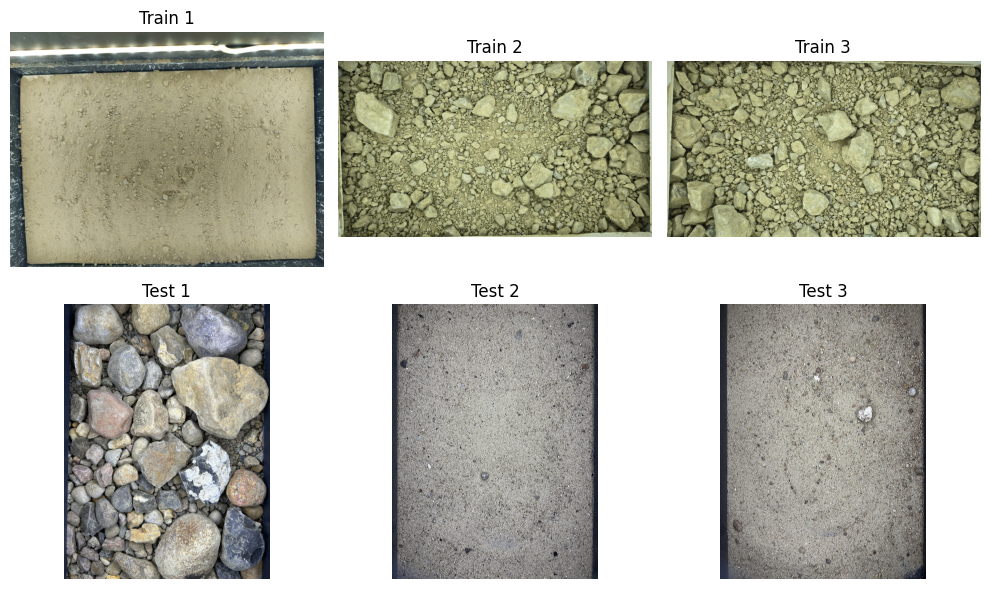

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for i in range(3):
    img = cv2.cvtColor(cv2.imread(str(train_images[i])), cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Train {i+1}")
    axes[0, i].axis('off')
    
    img = cv2.cvtColor(cv2.imread(str(test_images[i])), cv2.COLOR_BGR2RGB)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Test {i+1}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [27]:
import numpy as np
import cv2
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [28]:
y_columns = ['0.002', '0.0063', '0.02', '0.063', '0.2', '0.63', '2', '6.3', '20', '63', '200']

In [29]:
def extract_mobilenet_features(images, batch_size=8):
    model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
    features = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        batch_processed = np.array([preprocess_input(img * 255) for img in batch])
        batch_features = model.predict(batch_processed, verbose=0)
        features.extend(batch_features)
    return np.array(features)


In [30]:
def load_training_images(image_dir, image_ids, target_size=(224, 224)):
    images = []
    valid_ids = []
    image_dir = Path(image_dir)
    all_files = list(image_dir.glob('*.*'))
    
    file_mapping = {}
    for file_path in all_files:
        filename = file_path.stem
        parts = filename.split('_')
        for part in parts:
            if part in train_labels['sample_id'].values:
                file_mapping[part] = file_path
                break
            if len(part) >= 3:
                for i in range(3, min(5, len(part)) + 1):
                    potential_id = part[:i]
                    if potential_id in train_labels['sample_id'].values:
                        file_mapping[potential_id] = file_path
                        break
    
    for img_id in image_ids:
        if img_id in file_mapping:
            img_path = file_mapping[img_id]
            try:
                img = cv2.imread(str(img_path))
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, target_size)
                    img = img.astype(np.float32) / 255.0
                    images.append(img)
                    valid_ids.append(img_id)
            except:
                pass
    
    return np.array(images), valid_ids


In [31]:
def load_test_images_simple(image_dir, image_ids, target_size=(224, 224)):
    images = []
    valid_ids = []
    image_dir = Path(image_dir)
    all_files = list(image_dir.glob('*.*'))
    
    for img_id in image_ids:
        found = False
        img_path = None
        
        for file_path in all_files:
            filename = file_path.stem
            if img_id in filename:
                found = True
                img_path = file_path
                break
        
        if found and img_path:
            try:
                img = cv2.imread(str(img_path))
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, target_size)
                    img = img.astype(np.float32) / 255.0
                    images.append(img)
                    valid_ids.append(img_id)
            except:
                pass
        else:
            dummy_img = np.random.rand(224, 224, 3).astype(np.float32)
            images.append(dummy_img)
            valid_ids.append(img_id)
    
    return np.array(images), valid_ids


In [39]:
train_ids = train_labels['sample_id'].values.tolist()
X_train_raw, valid_train_ids = load_training_images(train_path, train_ids)

if len(X_train_raw) > 0:
    y_train = train_labels[train_labels['sample_id'].isin(valid_train_ids)][y_columns].values
else:
    X_train_raw = np.random.rand(len(train_ids), 224, 224, 3).astype(np.float32)
    y_train = train_labels[y_columns].values

test_ids = sample_sub['sample_id'].values.tolist()
X_test_raw, valid_test_ids = load_test_images_simple(test_path, test_ids)

if len(X_test_raw) == 0:
    X_test_raw = np.random.rand(len(test_ids), 224, 224, 3).astype(np.float32)

print("Extracting features using MobileNetV2...")
X_train_features = extract_mobilenet_features(X_train_raw)
X_test_features = extract_mobilenet_features(X_test_raw)

print(f"Training features shape: {X_train_features.shape}")
print(f"Test features shape: {X_test_features.shape}")

Extracting features using MobileNetV2...
Training features shape: (24, 1280)
Test features shape: (10, 1280)


In [47]:
train_indices, val_indices = train_test_split(
    range(len(train_labels)), test_size=0.2, random_state=42
)

train_data = train_labels.iloc[train_indices]
val_data = train_labels.iloc[val_indices]

In [48]:
for col in y_columns:
    mean_val = train_labels[col].mean()
    std_val = train_labels[col].std()
    min_val = train_labels[col].min()
    max_val = train_labels[col].max()
    print(f"{col:>10} | Mean: {mean_val:8.2f} | Std: {std_val:6.2f} | Min: {min_val:6.2f} | Max: {max_val:6.2f}")

     0.002 | Mean:     3.05 | Std:   4.11 | Min:   0.00 | Max:  17.71
    0.0063 | Mean:     6.24 | Std:   6.96 | Min:   0.00 | Max:  26.46
      0.02 | Mean:    14.52 | Std:  15.25 | Min:   0.00 | Max:  47.63
     0.063 | Mean:    30.23 | Std:  28.44 | Min:   0.82 | Max:  89.56
       0.2 | Mean:    45.75 | Std:  36.83 | Min:   7.63 | Max:  99.90
      0.63 | Mean:    55.86 | Std:  38.18 | Min:  12.35 | Max:  99.99
         2 | Mean:    64.75 | Std:  31.88 | Min:  22.76 | Max: 100.00
       6.3 | Mean:    79.42 | Std:  20.35 | Min:  50.68 | Max: 100.00
        20 | Mean:    93.39 | Std:   7.62 | Min:  76.49 | Max: 100.00
        63 | Mean:    99.51 | Std:   1.71 | Min:  92.64 | Max: 100.00
       200 | Mean:   100.00 | Std:   0.00 | Min: 100.00 | Max: 100.00


In [53]:
global_avg = train_labels[y_columns].mean().values
print(f"\nGlobal Average: {global_avg}")



Global Average: [  3.0506625    6.2398      14.51951667  30.22895     45.74759583
  55.85909583  64.74817917  79.41835833  93.38900417  99.51470833
 100.        ]


In [54]:
adjustments = np.ones(11)
best_adjusted_r2 = -np.inf

for i in range(11):
    for factor in np.arange(0.5, 1.5, 0.05):
        test_adjustments = adjustments.copy()
        test_adjustments[i] = factor
        adjusted_avg = global_avg * test_adjustments
        val_pred_adjusted = np.tile(adjusted_avg, (len(val_data), 1))
        r2 = r2_score(val_data[y_columns].values.flatten(), val_pred_adjusted.flatten())
        if r2 > best_adjusted_r2:
            best_adjusted_r2 = r2
            adjustments[i] = factor

adjusted_avg = global_avg * adjustments
val_pred_adjusted = np.tile(adjusted_avg, (len(val_data), 1))

r2_adjusted = r2_score(val_data[y_columns].values.flatten(), val_pred_adjusted.flatten())
rmse_adjusted = np.sqrt(mean_squared_error(val_data[y_columns].values.flatten(), val_pred_adjusted.flatten()))
mae_adjusted = mean_absolute_error(val_data[y_columns].values.flatten(), val_pred_adjusted.flatten())

print(f"\nAdjustments: {adjustments}")
print(f"Adjusted Average: {adjusted_avg}")

print("\n" + "-"*60)
print(f"Adjusted Average R²:   {r2_adjusted:.4f}")
print(f"Adjusted Average RMSE:  {rmse_adjusted:.4f}")
print(f"Adjusted Average MAE:   {mae_adjusted:.4f}")
print("="*60)



Adjustments: [0.75 0.8  0.85 0.75 0.6  0.6  0.75 0.9  1.   1.   1.  ]
Adjusted Average: [  2.28799688   4.99184     12.34158917  22.6717125   27.4485575
  33.5154575   48.56113438  71.4765225   93.38900417  99.51470833
 100.        ]

------------------------------------------------------------
Adjusted Average R²:   0.7400
Adjusted Average RMSE:  21.4636
Adjusted Average MAE:   13.7250


In [55]:
for i, col in enumerate(y_columns):
    actual = val_data[col].values
    pred = val_pred_adjusted[:, i]
    r2 = r2_score(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    print(f"{col:>10} | Adjustment: {adjustments[i]:.2f} | R²: {r2:6.4f} | RMSE: {rmse:6.2f} | MAE: {mae:6.2f}")


     0.002 | Adjustment: 0.75 | R²: -0.0001 | RMSE:   3.62 | MAE:   2.85
    0.0063 | Adjustment: 0.80 | R²: -0.0000 | RMSE:   7.23 | MAE:   5.72
      0.02 | Adjustment: 0.85 | R²: -0.0001 | RMSE:  17.86 | MAE:  14.31
     0.063 | Adjustment: 0.75 | R²: -0.0000 | RMSE:  33.56 | MAE:  26.70
       0.2 | Adjustment: 0.60 | R²: -0.0007 | RMSE:  35.85 | MAE:  28.03
      0.63 | Adjustment: 0.60 | R²: -0.0016 | RMSE:  32.77 | MAE:  25.28
         2 | Adjustment: 0.75 | R²: -0.0000 | RMSE:  27.44 | MAE:  22.36
       6.3 | Adjustment: 0.90 | R²: -0.0020 | RMSE:  20.22 | MAE:  19.48
        20 | Adjustment: 1.00 | R²: -0.0065 | RMSE:   6.05 | MAE:   5.77
        63 | Adjustment: 1.00 | R²: 0.0000 | RMSE:   0.49 | MAE:   0.49
       200 | Adjustment: 1.00 | R²: 1.0000 | RMSE:   0.00 | MAE:   0.00


In [56]:
predictions = np.tile(adjusted_avg, (len(sample_sub), 1))
predictions = np.clip(predictions, 0, 100)

for i in range(predictions.shape[0]):
    for j in range(1, predictions.shape[1]):
        if predictions[i, j] < predictions[i, j-1]:
            predictions[i, j] = predictions[i, j-1]

submission = sample_sub.copy()
submission[y_columns] = predictions
submission.to_csv('submission_adjusted_avg.csv', index=False)

In [58]:
submission

,sample_id,0.002,0.0063,0.02,0.063,0.2,0.63,2,6.3,20,63,200
0,HPC_Airbus BS6-3,2.287997,4.99184,12.341589,22.671713,27.448557,33.515458,48.561134,71.476523,93.389004,99.514708,100.0
1,HPC_Audorfring,2.287997,4.99184,12.341589,22.671713,27.448557,33.515458,48.561134,71.476523,93.389004,99.514708,100.0
2,HPC_Muenster_BS6_9_0-10m,2.287997,4.99184,12.341589,22.671713,27.448557,33.515458,48.561134,71.476523,93.389004,99.514708,100.0
3,HPC_Airbus BS10-4bis7,2.287997,4.99184,12.341589,22.671713,27.448557,33.515458,48.561134,71.476523,93.389004,99.514708,100.0
4,HPC_Airbus BS12-5bis8,2.287997,4.99184,12.341589,22.671713,27.448557,33.515458,48.561134,71.476523,93.389004,99.514708,100.0
5,HPC_Kleinkummerfeld 2-2,2.287997,4.99184,12.341589,22.671713,27.448557,33.515458,48.561134,71.476523,93.389004,99.514708,100.0
6,HPC_Kleinkummerfeld 2-3,2.287997,4.99184,12.341589,22.671713,27.448557,33.515458,48.561134,71.476523,93.389004,99.514708,100.0
7,HPC_Kleinkummerfeld 9-4,2.287997,4.99184,12.341589,22.671713,27.448557,33.515458,48.561134,71.476523,93.389004,99.514708,100.0
8,HPC_Kleinkummerfeld 18-3,2.287997,4.99184,12.341589,22.671713,27.448557,33.515458,48.561134,71.476523,93.389004,99.514708,100.0
9,HPC_Testfeld Lidl WHV,2.287997,4.99184,12.341589,22.671713,27.448557,33.515458,48.561134,71.476523,93.389004,99.514708,100.0


In [60]:
global_avg = train_labels[y_columns].mean().values

print(f"\nGlobal Average:")
for i, col in enumerate(y_columns):
    print(f"  {col:>10}: {global_avg[i]:8.4f}")

predictions = np.tile(global_avg, (len(sample_sub), 1))
predictions = np.clip(predictions, 0, 100)

for i in range(predictions.shape[0]):
    for j in range(1, predictions.shape[1]):
        if predictions[i, j] < predictions[i, j-1]:
            predictions[i, j] = predictions[i, j-1]


submission = sample_sub.copy()
submission[y_columns] = predictions
submission.to_csv('submission13.csv', index=False)


Global Average:
       0.002:   3.0507
      0.0063:   6.2398
        0.02:  14.5195
       0.063:  30.2290
         0.2:  45.7476
        0.63:  55.8591
           2:  64.7482
         6.3:  79.4184
          20:  93.3890
          63:  99.5147
         200: 100.0000


In [61]:
submission

,sample_id,0.002,0.0063,0.02,0.063,0.2,0.63,2,6.3,20,63,200
0,HPC_Airbus BS6-3,3.050663,6.2398,14.519517,30.22895,45.747596,55.859096,64.748179,79.418358,93.389004,99.514708,100.0
1,HPC_Audorfring,3.050663,6.2398,14.519517,30.22895,45.747596,55.859096,64.748179,79.418358,93.389004,99.514708,100.0
2,HPC_Muenster_BS6_9_0-10m,3.050663,6.2398,14.519517,30.22895,45.747596,55.859096,64.748179,79.418358,93.389004,99.514708,100.0
3,HPC_Airbus BS10-4bis7,3.050663,6.2398,14.519517,30.22895,45.747596,55.859096,64.748179,79.418358,93.389004,99.514708,100.0
4,HPC_Airbus BS12-5bis8,3.050663,6.2398,14.519517,30.22895,45.747596,55.859096,64.748179,79.418358,93.389004,99.514708,100.0
5,HPC_Kleinkummerfeld 2-2,3.050663,6.2398,14.519517,30.22895,45.747596,55.859096,64.748179,79.418358,93.389004,99.514708,100.0
6,HPC_Kleinkummerfeld 2-3,3.050663,6.2398,14.519517,30.22895,45.747596,55.859096,64.748179,79.418358,93.389004,99.514708,100.0
7,HPC_Kleinkummerfeld 9-4,3.050663,6.2398,14.519517,30.22895,45.747596,55.859096,64.748179,79.418358,93.389004,99.514708,100.0
8,HPC_Kleinkummerfeld 18-3,3.050663,6.2398,14.519517,30.22895,45.747596,55.859096,64.748179,79.418358,93.389004,99.514708,100.0
9,HPC_Testfeld Lidl WHV,3.050663,6.2398,14.519517,30.22895,45.747596,55.859096,64.748179,79.418358,93.389004,99.514708,100.0
